In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련
# 결측치 처리
from sklearn.impute import SimpleImputer

# 결측치 (Missing Value) 처리

### 연속성 수치형 데이터, 데이터가 정규분포 일 때
- 데이터 : 어느 고등학교 남학생 1000명의 키 데이터
- 특징 : 평균 175cm, 표준편차 5cm인 정규분포를 보이는 데이터
- 상황 : 데이터 기록 중 실수로 200명의 키 데이터가 누락된 상황

In [2]:
# 정규분포를 따르며 평균 175, 표준편차 5에 해당하는 데이터 1000개를 랜덤 발생시킨다.
np.random.seed(42)
# 데이터의 크기
data_size = 1000
# 데이터를 발생시킨다.
original_data = np.random.normal(loc=175, scale=5, size=data_size) # loc : 평균, scale : 표준편차
original_data

array([177.48357077, 174.30867849, 178.23844269, 182.61514928,
       173.82923313, 173.82931522, 182.89606408, 178.83717365,
       172.65262807, 177.71280022, 172.68291154, 172.67135123,
       176.20981136, 165.43359878, 166.37541084, 172.18856235,
       169.9358444 , 176.57123666, 170.45987962, 167.93848149,
       182.32824384, 173.8711185 , 175.33764102, 167.87625907,
       172.27808638, 175.55461295, 169.24503211, 176.87849009,
       171.99680655, 173.54153125, 171.99146694, 184.26139092,
       174.93251388, 169.71144536, 179.11272456, 168.89578175,
       176.04431798, 165.20164938, 168.35906976, 175.98430618,
       178.6923329 , 175.85684141, 174.42175859, 173.49448152,
       167.60739005, 171.40077896, 172.69680615, 180.28561113,
       176.71809145, 166.18479922, 176.62041985, 173.0745886 ,
       171.61539   , 178.05838144, 180.15499761, 179.6564006 ,
       170.80391238, 173.45393812, 176.65631716, 179.87772564,
       172.60412881, 174.07170512, 169.46832513, 169.01

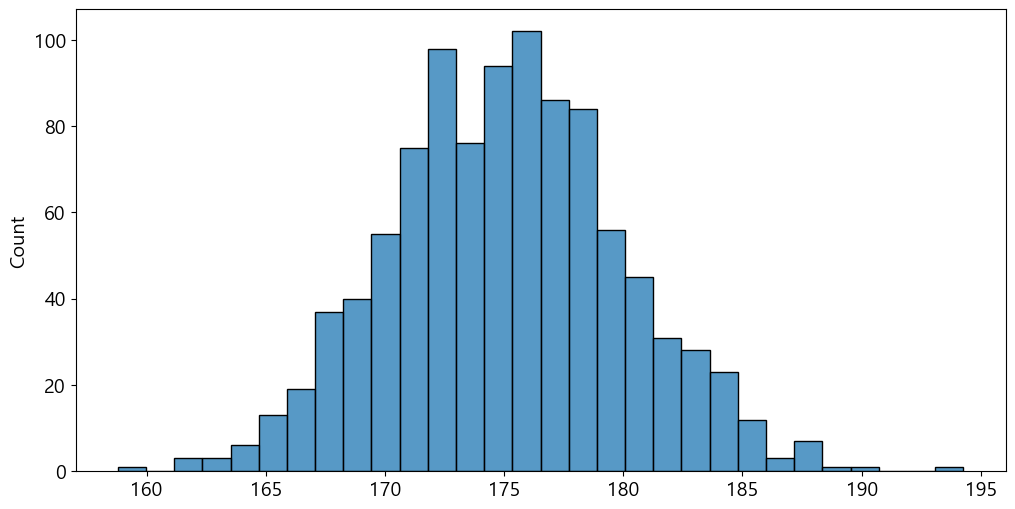

In [3]:
# 시각화를 해본다.
sns.histplot(original_data, bins=30)
plt.show()

In [4]:
# 데이터 프레임으로 변환
df = pd.DataFrame(original_data, columns=['키(Height)'])
df

,키(Height)
0,177.483571
1,174.308678
2,178.238443
3,182.615149
4,173.829233
...,...
995,173.594499
996,183.988433
997,178.204214
998,172.144105


In [5]:
# 전체 데이터의 순서값 중 랜덤하게 200개를 추출한다.
missing_indices = np.random.choice(data_size, size=200, replace=False)
# index가 missing_indices에 해당하는 데이터에 결측치를 넣어준다.
df_missing = df.copy()
df_missing.loc[missing_indices, '키(Height)'] = np.nan

# 결측치의 개수 확인
print(f'df_missing이 가지고 있는 결측치의 개수 : {df_missing.isna().sum()}')

df_missing이 가지고 있는 결측치의 개수 : 키(Height)    200
dtype: int64


In [6]:
# 결측치를 채워준다
# strategy : 결측치에 채워줄 값의 종류
# 연속형 수치형 데이터이고 정규분포를 보이므로 평균으로 지정한다.
df_filled = df_missing.copy()

imputer = SimpleImputer(strategy='mean')
df_filled['키(Height)'] = imputer.fit_transform(df_missing[['키(Height)']])
df_filled

,키(Height)
0,177.483571
1,174.308678
2,178.238443
3,175.012457
4,173.829233
...,...
995,173.594499
996,175.012457
997,178.204214
998,172.144105


In [8]:
print(f'df_filled가 가지고 있는 결측치의 개수 : {df_filled.isna().sum()}')

df_filled가 가지고 있는 결측치의 개수 : 키(Height)    0
dtype: int64


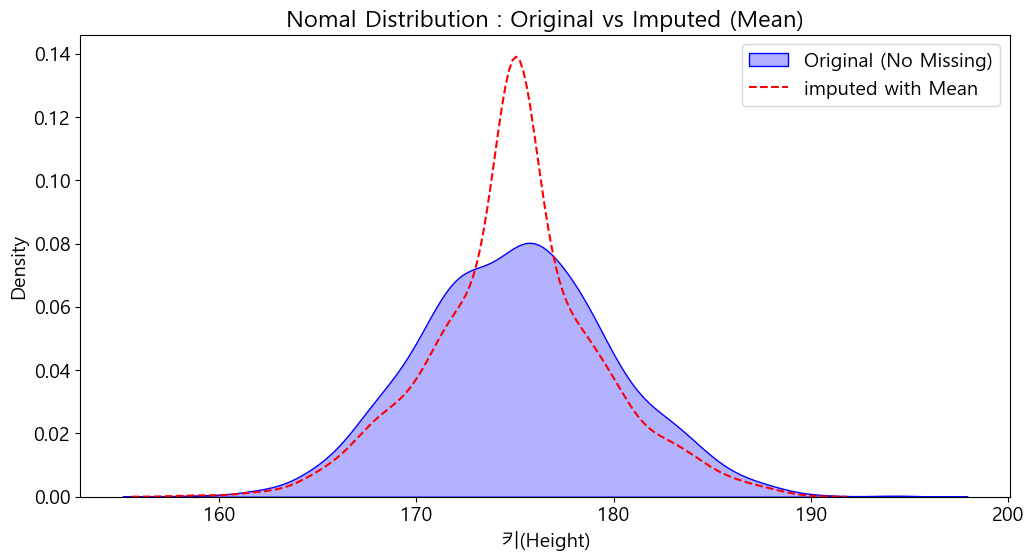

In [14]:
# 시각화
# 한 번에 비교를 하기 위해서 그래프를 중첩해서 그려본다.
# 원본 데이터
sns.kdeplot(df['키(Height)'], color = 'blue', label = 'Original (No Missing)', fill = True, alpha=0.3)

# 결측치를 평균으로 채워준 데이터
sns.kdeplot(df_filled['키(Height)'], color='red', linestyle='--', label = 'imputed with Mean')

plt.title('Nomal Distribution : Original vs Imputed (Mean)')
plt.legend()
plt.show()

In [20]:
# 통계치 비교
print(f'원본 평균 : {df['키(Height)'].mean():.2f}')
print(f'보정 평균 : {df_filled['키(Height)'].mean():.2f}')
print(f'원본 표준편차 : {df['키(Height)'].std():.2f}')
print(f'보정 표준편차 : {df_filled['키(Height)'].std():.2f}')

원본 평균 : 175.10
보정 평균 : 175.01
원본 표준편차 : 4.90
보정 표준편차 : 4.27


### 연속성 수치형 데이터, 데이터가 정규분포가 보이지 않을 떄
- 데이터 : 스타트업 직원들의 연봉(Salary) 데이터
- 특징 : 신입/주니어(3 ~ 4천만원)는 많고, 임원/CEO(수억원)는 적은 오른쪽 꼬리가 긴 분포
- 목표 : 결측치가 생겼을 때, 평균으로 채우는 것과 중앙 값으로 채우는 것의 차이를 눈으로 확인해본다.

In [25]:
# 치우친 데이터 생성
np.random.seed(42)
data_size =1000

# 지수 분포 활용(대부분 값이 작고, 일부 값이 매우 큼)
original_data = np.random.exponential(scale=1000, size=data_size) + 3000  # 평균 : 1000 + 3000
original_data

array([ 3469.26808998,  6010.12143092,  4316.74569355,  3912.94255378,
        3169.62487046,  3169.59629191,  3059.83876861,  5011.23086448,
        3919.08215363,  4231.2500617 ,  3020.799308  ,  6503.55747516,
        4786.42954335,  3238.68762525,  3200.67898875,  3202.61142283,
        3362.75372946,  3743.92783086,  3565.53706678,  3344.22299255,
        3946.3708739 ,  3150.23452873,  3345.515512  ,  3456.27721822,
        3608.93468786,  4537.93601103,  3222.73586213,  3722.02915503,
        3897.50472131,  3047.56384976,  3935.33302065,  3186.96125198,
        3067.26393088,  5973.68779351,  6370.63034246,  4652.33157281,
        3363.28785997,  3102.777315  ,  4152.7507631 ,  3580.09084259,
        3130.15223395,  3683.54722813,  3034.99372144,  5400.42288739,
        3299.45777684,  4086.25579856,  3373.54658166,  3734.11089591,
        3791.22379798,  3204.38859951,  6492.80713274,  4492.24537714,
        5805.09441929,  5252.15199753,  3911.05441238,  5549.43537927,
      

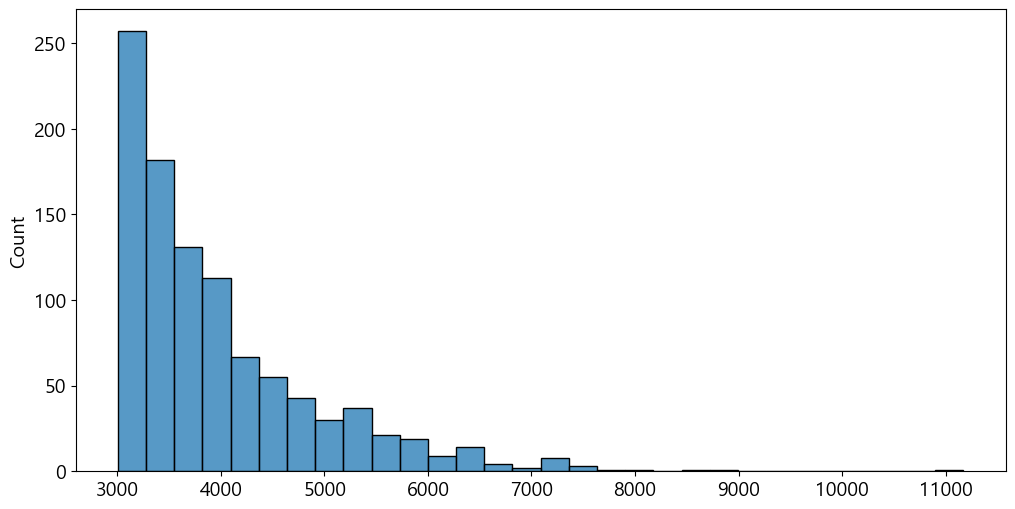

In [26]:
# 시각화
sns.histplot(original_data, bins=30)
plt.show()

In [28]:
# 데이터 프레임을 생성한다.
df = pd.DataFrame(original_data, columns=['연봉'])
df

,연봉
0,3469.268090
1,6010.121431
2,4316.745694
3,3912.942554
4,3169.624870
...,...
995,3096.050735
996,5492.699844
997,3147.130449
998,6000.490653


In [32]:
# 위의 데이터 중 200개를 결측치로 변경한다.
missing_indices = np.random.choice(data_size, size=200, replace=False)
df_missing = df.copy()
df_missing.loc[missing_indices, '연봉'] = np.nan
df_missing.isna().sum()

연봉    200
dtype: int64

In [35]:
# 평균을 구해 채워준다.
imputer_mean = SimpleImputer(strategy='mean')
df_mean = df_missing.copy()
df_mean['연봉'] = imputer_mean.fit_transform(df_missing[['연봉']])

In [37]:
# 중앙값을 구해 채워준다.
imputer_median = SimpleImputer(strategy='median')
df_median = df_missing.copy()
df_median['연봉'] = imputer_median.fit_transform(df_missing[['연봉']])

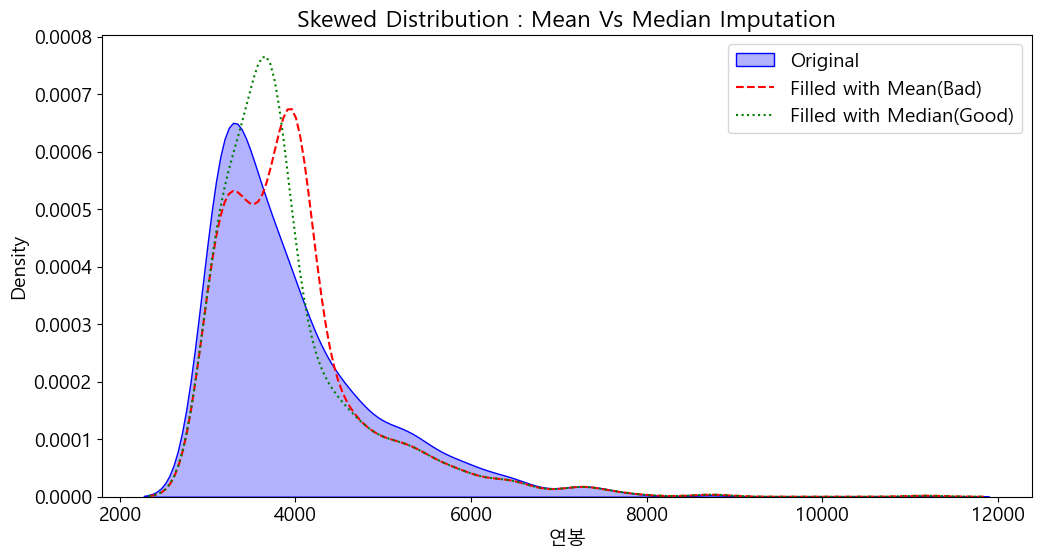

In [38]:
# 원본
sns.kdeplot(df['연봉'], fill = True, color='blue', alpha=0.3, label='Original')
# 평균으로 대치
sns.kdeplot(df_mean['연봉'], color='red', linestyle='--', label='Filled with Mean(Bad)')
# 중앙값으로 대치
sns.kdeplot(df_median['연봉'], color='green', linestyle=':', label='Filled with Median(Good)')

plt.title('Skewed Distribution : Mean Vs Median Imputation')
plt.legend()
plt.show()

In [49]:
# 통계 비교
print(f'원본 평균 : {np.mean(df['연봉']):.2f}')
print(f'평균으로 채운 평균 : {np.mean(df_mean['연봉']):.2f}')
print(f'중앙값으로 채운 평균 : {np.mean(df_median['연봉']):.2f}')
print()
print(f'원본 표준편차 : {np.std(df['연봉']):.2f}')
print(f'평균으로 채운 표준편차 : {np.std(df_mean['연봉']):.2f}')
print(f'중앙값으로 채운 표준편차 : {np.std(df_median['연봉']):.2f}')
print()
print(f'원본 중앙값 : {np.median(df['연봉']):.2f}')
print(f'평균으로 채운 중앙값 : {np.median(df_mean['연봉']):.2f}')
print(f'중앙값으로 채운 중앙값 : {np.median(df_median['연봉']):.2f}')


원본 평균 : 3972.51
평균으로 채운 평균 : 3985.81
중앙값으로 채운 평균 : 3928.35

원본 표준편차 : 972.02
평균으로 채운 표준편차 : 890.44
중앙값으로 채운 표준편차 : 897.83

원본 중앙값 : 3686.78
평균으로 채운 중앙값 : 3959.81
중앙값으로 채운 중앙값 : 3698.48


### 범주형 데이터
- 데이터 : OTT 서비스와 같은 구독 멤버십 등급 데이터 (Basic, Standard, Premium)\
- 특징 : 가장 저렴한 Basic이 가장 많이 있다(60%)
- 상황 : 전산 오류로 일부 회원의 멤버십 정보가 삭제 됬다.
- 전략 : "모르겠다면 일단 제일 많이 쓰는 요금제라고 가정하자"

In [50]:
# 범주형 데이터로 생성한다. Basic이 60%로 가장 많게
np.random.seed(42)
data_size = 1000
categories = ['Basic', 'Standard', 'Premium']
# 각 데이터가 추출될 확률
probs = [0.6, 0.3, 0.1]

original_data = np.random.choice(categories, size=data_size, p=probs)
original_data

array(['Basic', 'Premium', 'Standard', 'Basic', 'Basic', 'Basic', 'Basic',
       'Standard', 'Standard', 'Standard', 'Basic', 'Premium', 'Standard',
       'Basic', 'Basic', 'Basic', 'Basic', 'Basic', 'Basic', 'Basic',
       'Standard', 'Basic', 'Basic', 'Basic', 'Basic', 'Standard',
       'Basic', 'Basic', 'Basic', 'Basic', 'Standard', 'Basic', 'Basic',
       'Premium', 'Premium', 'Standard', 'Basic', 'Basic', 'Standard',
       'Basic', 'Basic', 'Basic', 'Basic', 'Premium', 'Basic', 'Standard',
       'Basic', 'Basic', 'Basic', 'Basic', 'Premium', 'Standard',
       'Premium', 'Standard', 'Basic', 'Premium', 'Basic', 'Basic',
       'Basic', 'Basic', 'Basic', 'Basic', 'Standard', 'Basic', 'Basic',
       'Basic', 'Basic', 'Standard', 'Basic', 'Premium', 'Standard',
       'Basic', 'Basic', 'Standard', 'Standard', 'Standard', 'Standard',
       'Basic', 'Basic', 'Basic', 'Standard', 'Standard', 'Basic',
       'Basic', 'Basic', 'Basic', 'Standard', 'Standard', 'Standard',
       '

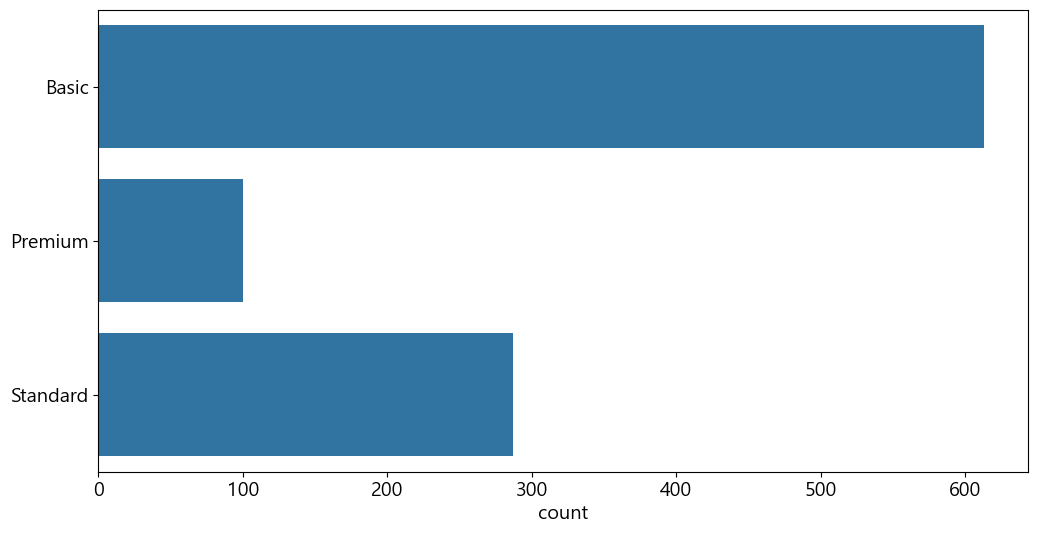

In [52]:
sns.countplot(original_data)
plt.show()

In [56]:
df = pd.DataFrame(original_data, columns=['멤버십'])
df

,멤버십
0,Basic
1,Premium
2,Standard
3,Basic
4,Basic
...,...
995,Basic
996,Premium
997,Basic
998,Premium


In [57]:
# 결측치 생성 (200개)
missing_indicies = np.random.choice(data_size, size=200, replace=False)
df_missing = df.copy()
df_missing.loc[missing_indices, '멤버십'] = np.nan
df_missing.isna().sum()

멤버십    200
dtype: int64

In [60]:
# 범주형 데이터는 무조건 최빈값!!
imputer = SimpleImputer(strategy='most_frequent')
df_filled = df_missing.copy()
df_filled['멤버십'] = imputer.fit_transform(df_missing[['멤버십']]).reshape(-1)
df_filled.isna().sum()

멤버십    0
dtype: int64

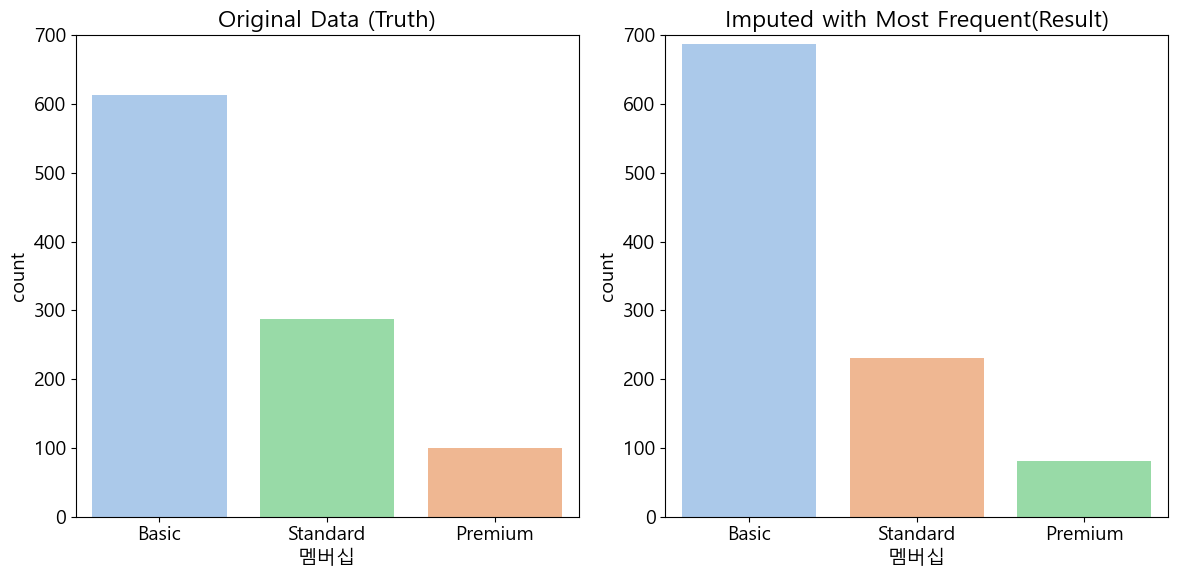

In [63]:
# 원본
plt.subplot(1,2,1)
sns.countplot(data=df, x='멤버십', order=categories, palette='pastel', hue='멤버십')
plt.title('Original Data (Truth)')
plt.ylim(0,700)

# 최빈값으로 채워준 것
plt.subplot(1,2,2)
sns.countplot(data=df_filled, x='멤버십', order=categories, palette='pastel', hue='멤버십')
plt.title('Imputed with Most Frequent(Result)')
plt.ylim(0, 700)

plt.tight_layout()
plt.show()

In [67]:
# 통계값 확인
print('원본')
print(df['멤버십'].value_counts())
print()
print('최빈값으로 채워준 것')
print(df_filled['멤버십'].value_counts())

원본
멤버십
Basic       613
Standard    287
Premium     100
Name: count, dtype: int64

최빈값으로 채워준 것
멤버십
Basic       688
Standard    231
Premium      81
Name: count, dtype: int64
